# Binary Classification Capstone Project
## Breast Cancer Detection using Machine Learning

### Project Overview
In this capstone project, we will build a **binary classification model** to predict whether a breast tumor is **Malignant (cancerous)** or **Benign (non-cancerous)**.

### Dataset
We'll use the **Breast Cancer Wisconsin Dataset** from sklearn, which contains:
- **569 samples**
- **30 features** (computed from digitized images of breast mass)
- **2 classes**: Malignant (1) and Benign (0)

### Project Steps
1. Load and explore the dataset
2. Data cleaning and preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Train multiple ML models
6. Model evaluation and comparison
7. Save the best model

---
## Step 1: Import Required Libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Model persistence
import pickle

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


---
## Step 2: Load the Dataset

In [3]:
# Load the breast cancer dataset
data = load_breast_cancer()

# Create a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")  # -1 because target is included

Dataset loaded successfully!

Dataset Shape: (569, 31)
Number of samples: 569
Number of features: 30


---
## Step 3: Understand the Dataset

In [4]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
# Display basic information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoot

In [6]:
# Display target distribution
print("\nTarget Distribution:")
print(df['target'].value_counts())
print("\nTarget Labels:")
print("0 = Malignant (Cancerous)")
print("1 = Benign (Non-cancerous)")

# Percentage distribution
print("\nPercentage Distribution:")
print(df['target'].value_counts(normalize=True) * 100)


Target Distribution:
target
1    357
0    212
Name: count, dtype: int64

Target Labels:
0 = Malignant (Cancerous)
1 = Benign (Non-cancerous)

Percentage Distribution:
target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


---
## Step 4: Data Cleaning

We need to check for:
- Missing values
- Duplicate rows
- Data types
- Outliers

In [7]:
# Check for missing values
print("Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\n✓ No missing values found!")
else:
    print(f"\n⚠ Total missing values: {missing_values.sum()}")

Missing Values:
Series([], dtype: int64)

✓ No missing values found!


In [8]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates == 0:
    print("✓ No duplicate rows found!")
else:
    print(f"⚠ Removing {duplicates} duplicate rows...")
    df = df.drop_duplicates()
    print("✓ Duplicates removed!")

Number of duplicate rows: 0
✓ No duplicate rows found!


In [9]:
# Display statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


---
## Step 5: Exploratory Data Analysis (EDA)

Let's visualize the data to understand patterns and relationships.

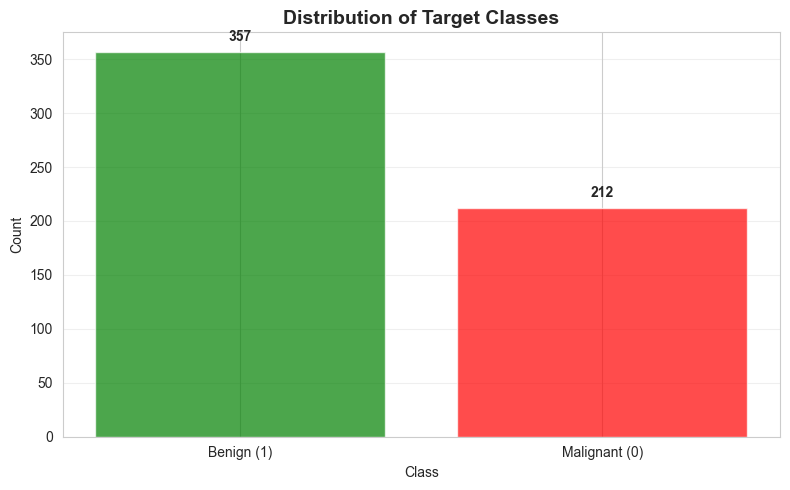

The dataset is relatively balanced with more benign cases than malignant.


In [10]:
# Visualize target distribution
plt.figure(figsize=(8, 5))
target_counts = df['target'].value_counts()
plt.bar(['Benign (1)', 'Malignant (0)'], target_counts.values, color=['green', 'red'], alpha=0.7)
plt.title('Distribution of Target Classes', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("The dataset is relatively balanced with more benign cases than malignant.")

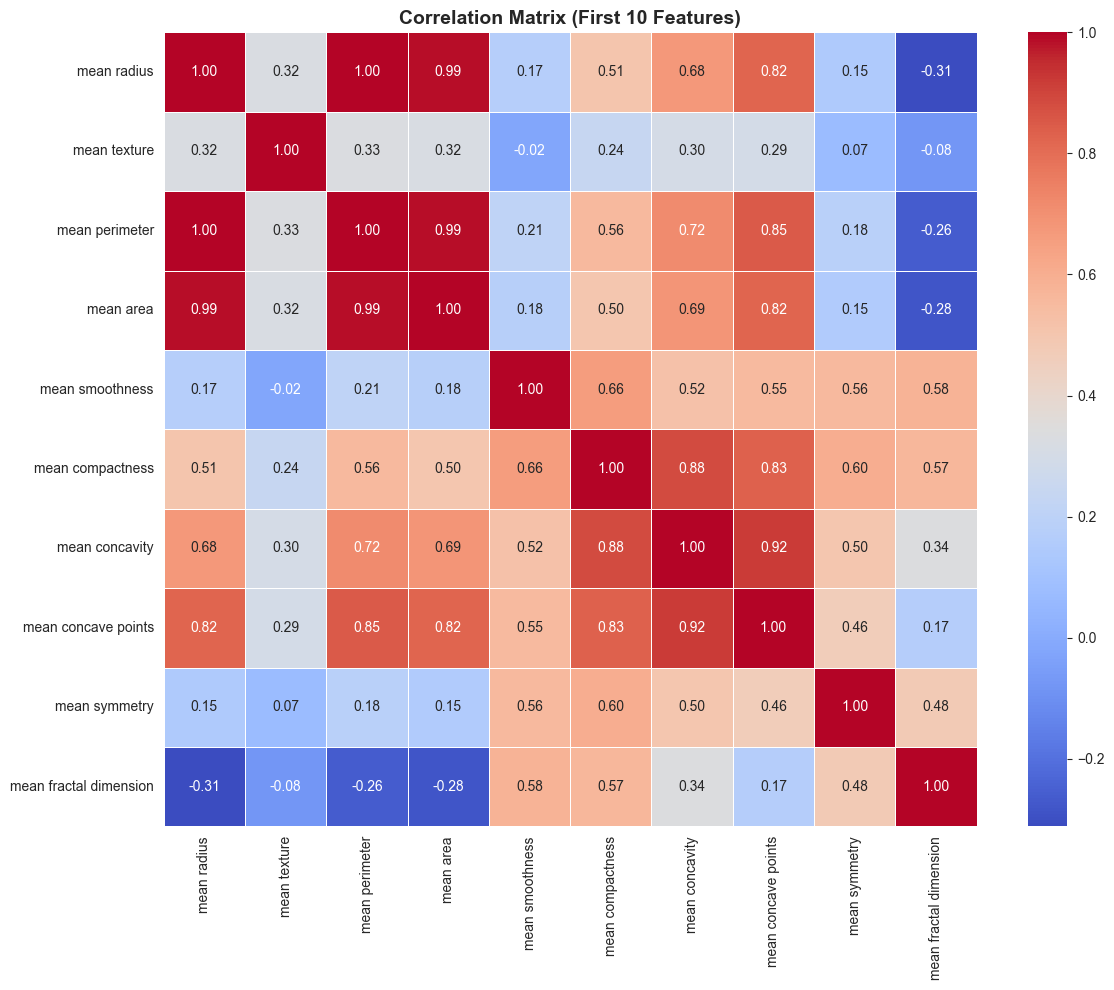

This heatmap shows correlations between features. Highly correlated features may be redundant.


In [11]:
# Correlation matrix for first 10 features (for readability)
plt.figure(figsize=(12, 10))
correlation = df.iloc[:, :10].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (First 10 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("This heatmap shows correlations between features. Highly correlated features may be redundant.")

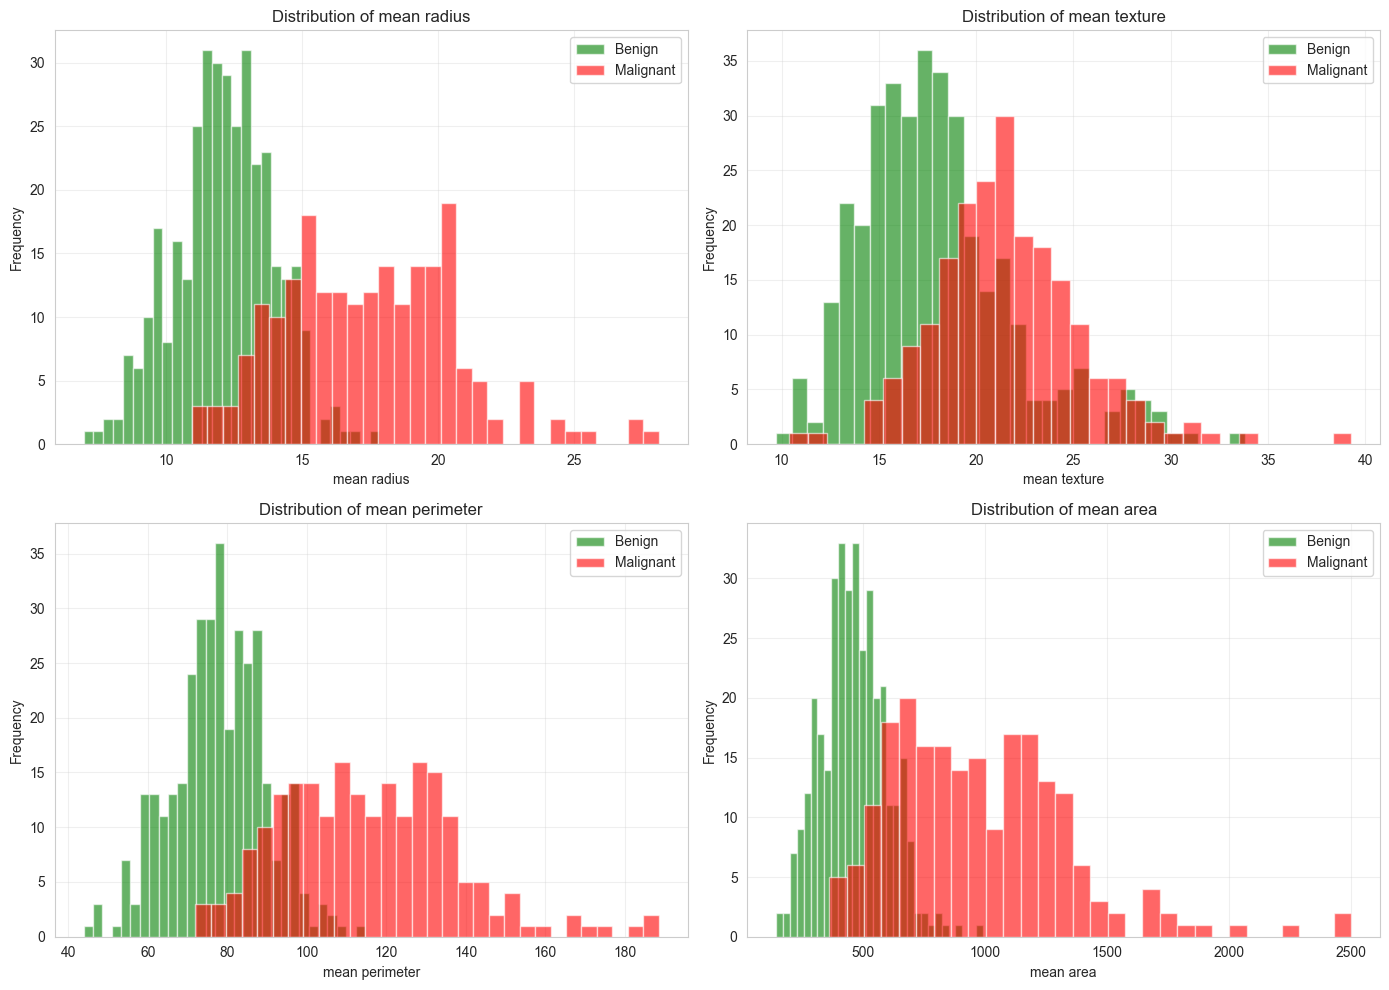

These histograms show how feature distributions differ between benign and malignant tumors.


In [12]:
# Distribution of key features by target class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Select 4 important features to visualize
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

for i, feature in enumerate(features_to_plot):
    row = i // 2
    col = i % 2
    
    # Separate data by target
    benign = df[df['target'] == 1][feature]
    malignant = df[df['target'] == 0][feature]
    
    axes[row, col].hist(benign, bins=30, alpha=0.6, label='Benign', color='green')
    axes[row, col].hist(malignant, bins=30, alpha=0.6, label='Malignant', color='red')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Distribution of {feature}')
    axes[row, col].legend()
    axes[row, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("These histograms show how feature distributions differ between benign and malignant tumors.")

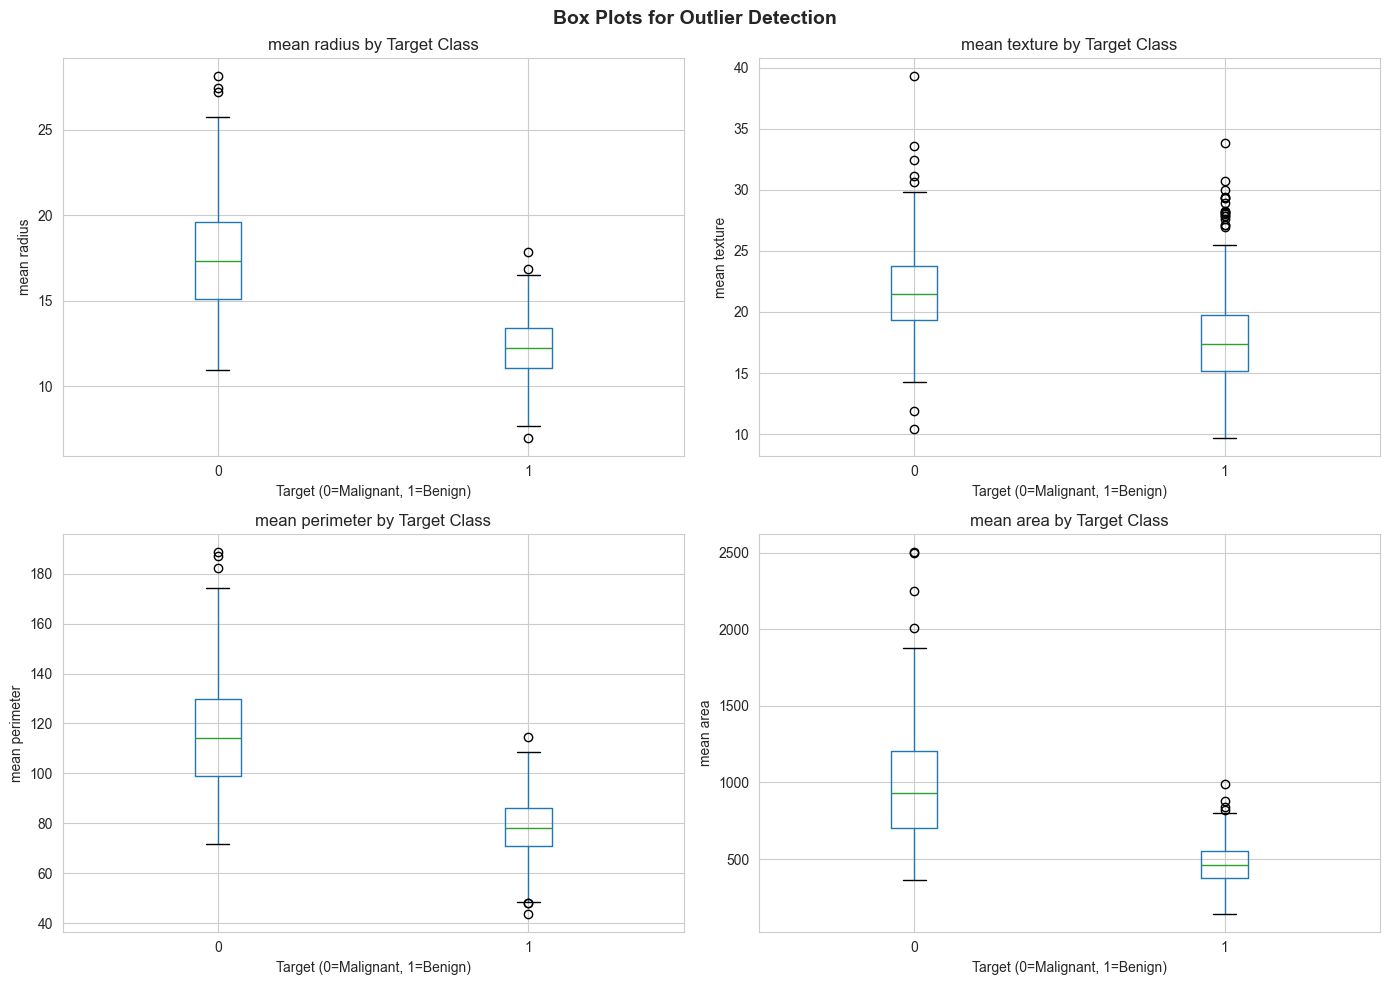

Box plots help identify outliers (points outside the whiskers).


In [13]:
# Box plots to detect outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, feature in enumerate(features_to_plot):
    row = i // 2
    col = i % 2
    
    df.boxplot(column=feature, by='target', ax=axes[row, col])
    axes[row, col].set_xlabel('Target (0=Malignant, 1=Benign)')
    axes[row, col].set_ylabel(feature)
    axes[row, col].set_title(f'{feature} by Target Class')

plt.suptitle('Box Plots for Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Box plots help identify outliers (points outside the whiskers).")

---
## Step 6: Feature Engineering

We'll create new features and select the most important ones.

In [14]:
# Create new features
# Example: Ratio features can be helpful
df['radius_to_texture_ratio'] = df['mean radius'] / (df['mean texture'] + 1)  # +1 to avoid division by zero
df['area_to_perimeter_ratio'] = df['mean area'] / (df['mean perimeter'] + 1)
df['smoothness_compactness_interaction'] = df['mean smoothness'] * df['mean compactness']

print("✓ New features created:")
print("  - radius_to_texture_ratio")
print("  - area_to_perimeter_ratio")
print("  - smoothness_compactness_interaction")
print(f"\nTotal features now: {df.shape[1] - 1}")  # -1 for target

✓ New features created:
  - radius_to_texture_ratio
  - area_to_perimeter_ratio
  - smoothness_compactness_interaction

Total features now: 33


In [15]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (569, 33)
Target shape: (569,)


Top 10 features most correlated with target:
target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
radius_to_texture_ratio   -0.317436
worst fractal dimension   -0.323872
mean symmetry             -0.330499
Name: target, dtype: float64


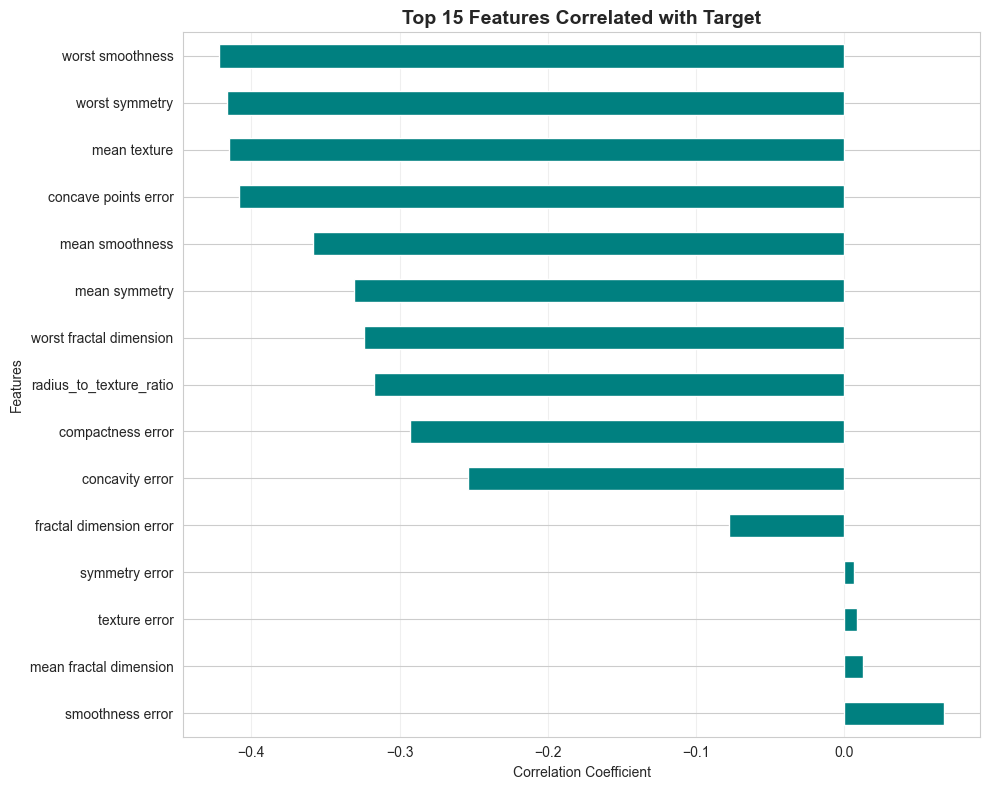

In [16]:
# Feature correlation with target
feature_target_corr = df.corr()['target'].sort_values(ascending=False)
print("Top 10 features most correlated with target:")
print(feature_target_corr.head(11))  # 11 because target itself is included

# Visualize
plt.figure(figsize=(10, 8))
feature_target_corr[1:16].plot(kind='barh', color='teal')  # Top 15 features excluding target
plt.title('Top 15 Features Correlated with Target', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 7: Data Splitting

Split the data into training and testing sets (80-20 split).

In [17]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set size: 455 samples
Testing set size: 114 samples

Training set shape: (455, 33)
Testing set shape: (114, 33)


---
## Step 8: Feature Scaling

Many ML algorithms perform better with scaled features.

In [18]:
# Standardize the features (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled successfully!")
print(f"\nOriginal feature range (example - mean radius):")
print(f"  Min: {X_train['mean radius'].min():.2f}, Max: {X_train['mean radius'].max():.2f}")
print(f"\nScaled feature range (example - mean radius):")
print(f"  Min: {X_train_scaled[:, 0].min():.2f}, Max: {X_train_scaled[:, 0].max():.2f}")

✓ Features scaled successfully!

Original feature range (example - mean radius):
  Min: 6.98, Max: 28.11

Scaled feature range (example - mean radius):
  Min: -2.03, Max: 4.02


---
## Step 9: Train Multiple ML Models

We'll train 8 different classification algorithms and compare their performance.

In [19]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=10000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=50, algorithm='SAMME'),
    'Support Vector Machine': SVC(random_state=42, probability=True),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

print(f"✓ Initialized {len(models)} models for training")
print("\nModels to be trained:")
for i, model_name in enumerate(models.keys(), 1):
    print(f"  {i}. {model_name}")

✓ Initialized 8 models for training

Models to be trained:
  1. Logistic Regression
  2. Decision Tree
  3. Random Forest
  4. Gradient Boosting
  5. AdaBoost
  6. Support Vector Machine
  7. K-Nearest Neighbors
  8. Naive Bayes


In [20]:
# Train all models and store results
results = {}
trained_models = {}

print("Training models...\n")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC-AUC score
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = roc_auc_score(y_test, y_pred)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    cv_mean = cv_scores.mean()
    
    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'CV Score': cv_mean
    }
    
    # Store trained model
    trained_models[name] = model
    
    print(f"  ✓ Accuracy: {accuracy:.4f} | F1-Score: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")

print("\n" + "=" * 80)
print("✓ All models trained successfully!")

Training models...


Training Logistic Regression...
  ✓ Accuracy: 0.9737 | F1-Score: 0.9790 | ROC-AUC: 0.9950

Training Decision Tree...
  ✓ Accuracy: 0.9123 | F1-Score: 0.9296 | ROC-AUC: 0.9107

Training Random Forest...
  ✓ Accuracy: 0.9474 | F1-Score: 0.9583 | ROC-AUC: 0.9932

Training Gradient Boosting...
  ✓ Accuracy: 0.9561 | F1-Score: 0.9660 | ROC-AUC: 0.9878

Training AdaBoost...
  ✓ Accuracy: 0.9561 | F1-Score: 0.9660 | ROC-AUC: 0.9815

Training Support Vector Machine...
  ✓ Accuracy: 0.9737 | F1-Score: 0.9790 | ROC-AUC: 0.9950

Training K-Nearest Neighbors...
  ✓ Accuracy: 0.9561 | F1-Score: 0.9655 | ROC-AUC: 0.9901

Training Naive Bayes...
  ✓ Accuracy: 0.9298 | F1-Score: 0.9444 | ROC-AUC: 0.9838

✓ All models trained successfully!


---
## Step 10: Model Comparison

Let's compare all models and identify the best performer.

In [21]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Accuracy', ascending=False)

print("Model Performance Comparison:")
print("=" * 100)
print(results_df.to_string())
print("=" * 100)

Model Performance Comparison:
                        Accuracy  Precision    Recall  F1-Score   ROC-AUC  CV Score
Logistic Regression     0.973684   0.985915  0.972222  0.979021  0.995040  0.982418
Support Vector Machine  0.973684   0.985915  0.972222  0.979021  0.995040  0.971429
Gradient Boosting       0.956140   0.946667  0.986111  0.965986  0.987765  0.958242
AdaBoost                0.956140   0.946667  0.986111  0.965986  0.981481  0.969231
K-Nearest Neighbors     0.956140   0.958904  0.972222  0.965517  0.990079  0.964835
Random Forest           0.947368   0.958333  0.958333  0.958333  0.993221  0.960440
Naive Bayes             0.929825   0.944444  0.944444  0.944444  0.983796  0.931868
Decision Tree           0.912281   0.942857  0.916667  0.929577  0.910714  0.931868


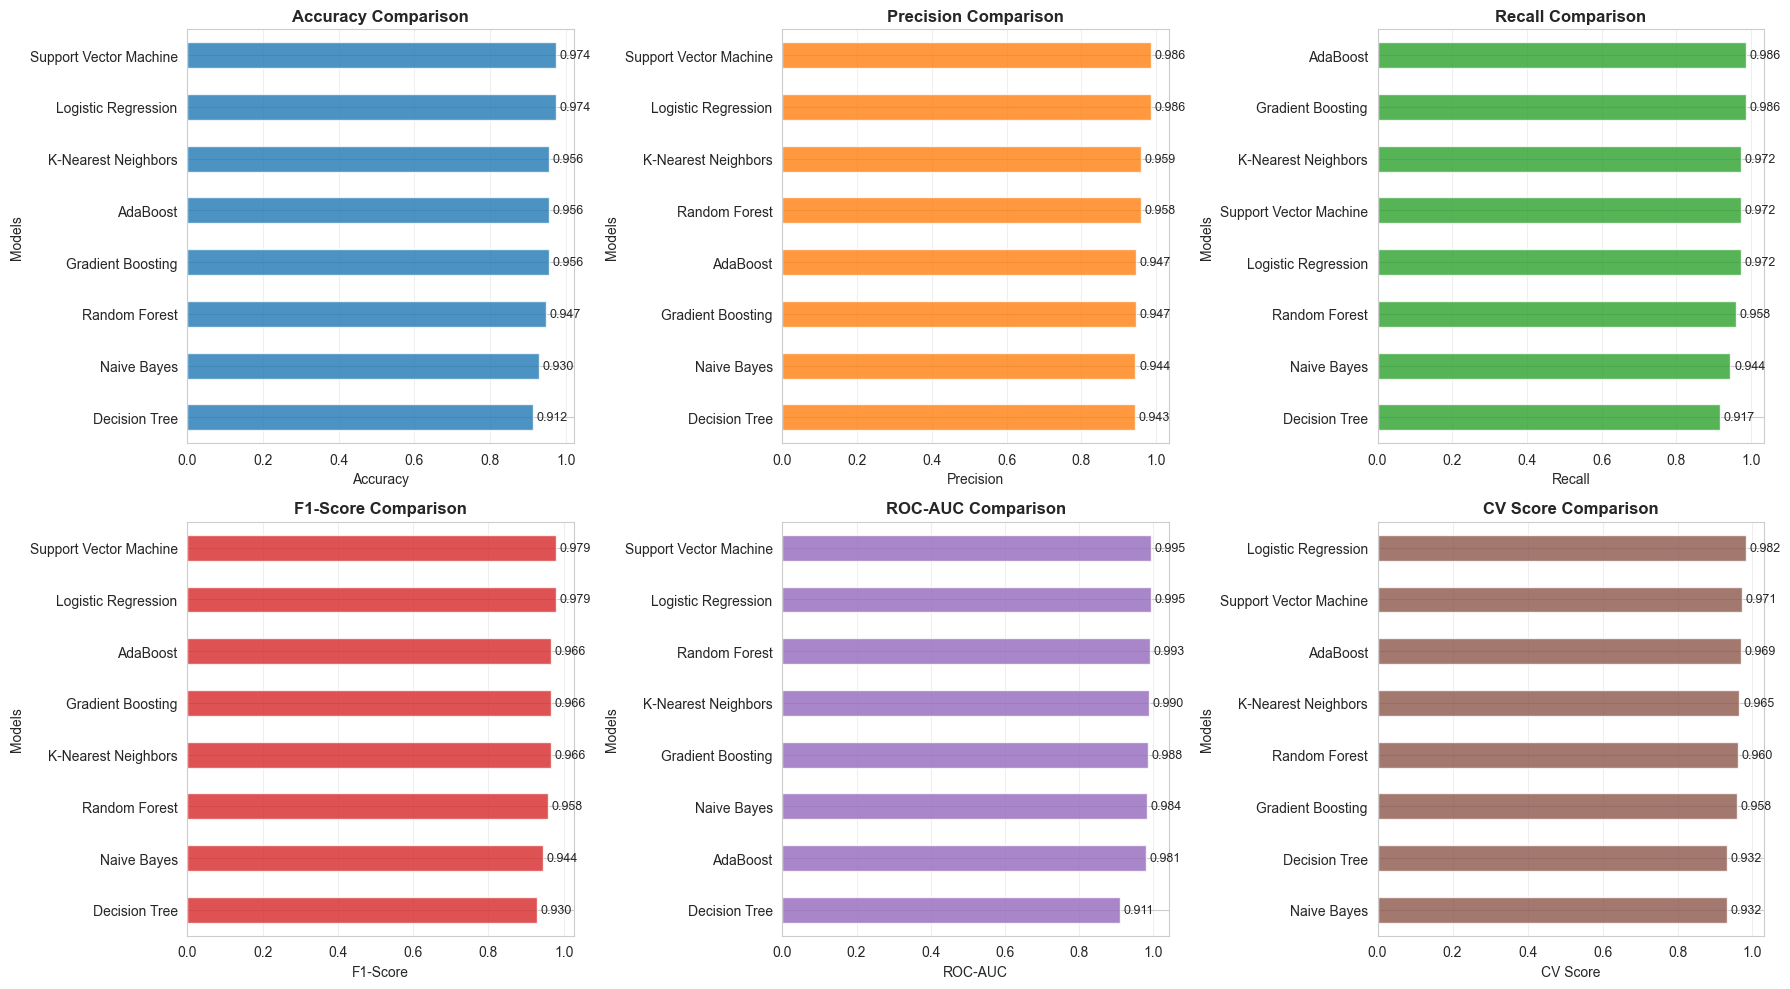

In [22]:
# Visualize model comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3
    
    ax = axes[row, col]
    results_df[metric].sort_values(ascending=True).plot(
        kind='barh', ax=ax, color=colors[idx], alpha=0.8
    )
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)
    ax.set_ylabel('Models')
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(results_df[metric].sort_values(ascending=True)):
        ax.text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
# Identify the best model based on multiple metrics
# We'll use a weighted average: Accuracy (30%), F1 (30%), ROC-AUC (30%), CV (10%)
results_df['Overall Score'] = (
    results_df['Accuracy'] * 0.3 +
    results_df['F1-Score'] * 0.3 +
    results_df['ROC-AUC'] * 0.3 +
    results_df['CV Score'] * 0.1
)

results_df = results_df.sort_values('Overall Score', ascending=False)

best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print("\n" + "=" * 100)
print(f"🏆 BEST PERFORMING MODEL: {best_model_name}")
print("=" * 100)
print(f"\nOverall Score: {results_df.loc[best_model_name, 'Overall Score']:.4f}")
print(f"\nDetailed Metrics:")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV Score']:
    print(f"  {metric:.<20} {results_df.loc[best_model_name, metric]:.4f}")
print("=" * 100)


🏆 BEST PERFORMING MODEL: Logistic Regression

Overall Score: 0.9826

Detailed Metrics:
  Accuracy............ 0.9737
  Precision........... 0.9859
  Recall.............. 0.9722
  F1-Score............ 0.9790
  ROC-AUC............. 0.9950
  CV Score............ 0.9824


---
## Step 11: Detailed Analysis of Best Model

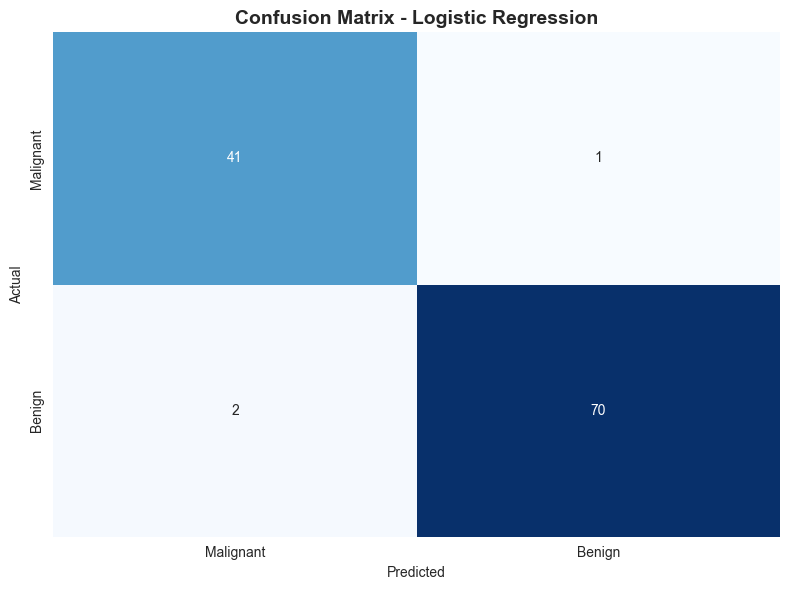


Confusion Matrix Interpretation:
  True Negatives (Malignant correctly predicted): 41
  False Positives (Malignant predicted as Benign): 1
  False Negatives (Benign predicted as Malignant): 2
  True Positives (Benign correctly predicted): 70


In [24]:
# Get predictions from best model
y_pred_best = best_model.predict(X_test_scaled)
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1] if hasattr(best_model, 'predict_proba') else None

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
print(f"  True Negatives (Malignant correctly predicted): {cm[0, 0]}")
print(f"  False Positives (Malignant predicted as Benign): {cm[0, 1]}")
print(f"  False Negatives (Benign predicted as Malignant): {cm[1, 0]}")
print(f"  True Positives (Benign correctly predicted): {cm[1, 1]}")

In [25]:
# Classification Report
print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_best, target_names=['Malignant', 'Benign']))
print("=" * 60)


Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.98      0.96        42
      Benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



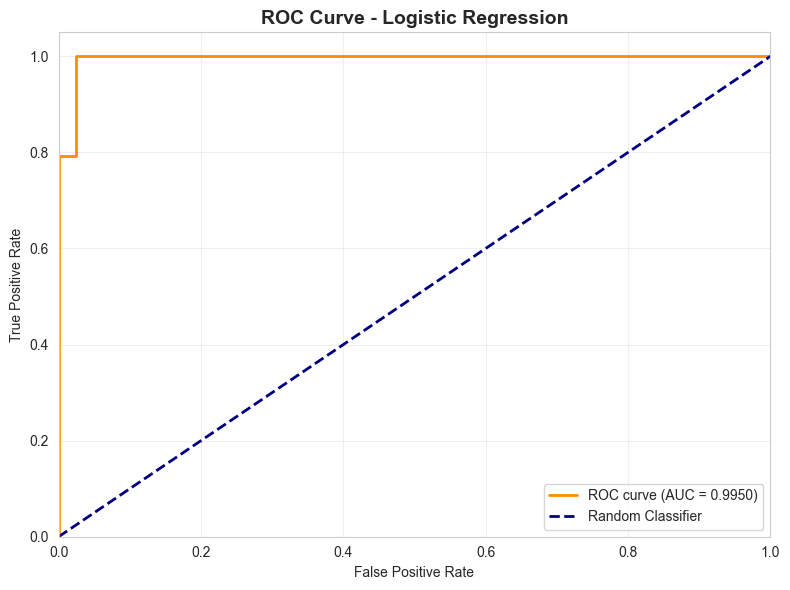


ROC-AUC Score: 0.9950
An AUC close to 1.0 indicates excellent model performance!


In [26]:
# ROC Curve
if y_pred_proba_best is not None:
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
    roc_auc = roc_auc_score(y_test, y_pred_proba_best)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {best_model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nROC-AUC Score: {roc_auc:.4f}")
    print("An AUC close to 1.0 indicates excellent model performance!")

---
## Step 12: Feature Importance (if applicable)

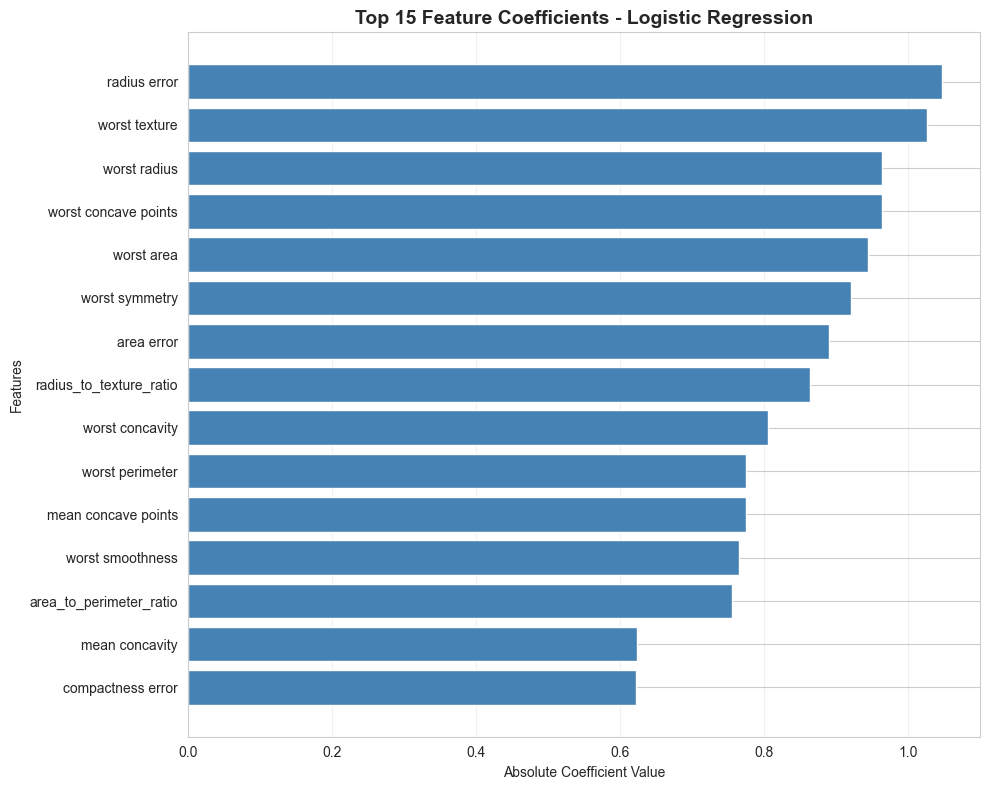


Top 10 Most Important Features:
                feature  coefficient
           radius error     1.047785
          worst texture     1.026424
           worst radius     0.964424
   worst concave points     0.964222
             worst area     0.944645
         worst symmetry     0.920960
             area error     0.890462
radius_to_texture_ratio     0.863727
        worst concavity     0.805929
        worst perimeter     0.775014


In [27]:
# Check if the model has feature importance
if hasattr(best_model, 'feature_importances_'):
    # Get feature importances
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Plot top 15 important features
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance['feature'].head(15), 
             feature_importance['importance'].head(15),
             color='steelblue')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.title(f'Top 15 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))
    
elif hasattr(best_model, 'coef_'):
    # For linear models like Logistic Regression
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'coefficient': abs(best_model.coef_[0])
    }).sort_values('coefficient', ascending=False)
    
    # Plot top 15 important features
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance['feature'].head(15), 
             feature_importance['coefficient'].head(15),
             color='steelblue')
    plt.xlabel('Absolute Coefficient Value')
    plt.ylabel('Features')
    plt.title(f'Top 15 Feature Coefficients - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))
    
else:
    print(f"\n{best_model_name} does not provide feature importance or coefficients.")

---
## Step 13: Save the Best Model

We'll save the best model and the scaler for future use.

In [28]:
# Save the best model
model_filename = 'best_breast_cancer_model.pkl'
scaler_filename = 'feature_scaler.pkl'

# Save model
with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)

# Save scaler
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)

print(f"✓ Best model saved as: {model_filename}")
print(f"✓ Feature scaler saved as: {scaler_filename}")
print(f"\nModel: {best_model_name}")
print(f"Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}")

✓ Best model saved as: best_breast_cancer_model.pkl
✓ Feature scaler saved as: feature_scaler.pkl

Model: Logistic Regression
Accuracy: 0.9737


---
## Step 14: Load and Test Saved Model

Let's verify that the saved model works correctly.

In [29]:
# Load the saved model and scaler
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)

with open(scaler_filename, 'rb') as file:
    loaded_scaler = pickle.load(file)

print("✓ Model and scaler loaded successfully!")

✓ Model and scaler loaded successfully!


In [30]:
# Test with a sample prediction
# Take the first sample from test set
sample = X_test.iloc[0:1]
sample_scaled = loaded_scaler.transform(sample)
prediction = loaded_model.predict(sample_scaled)
actual = y_test.iloc[0]

print("\n" + "=" * 60)
print("SAMPLE PREDICTION TEST")
print("=" * 60)
print(f"\nPredicted class: {prediction[0]} ({'Benign' if prediction[0] == 1 else 'Malignant'})")
print(f"Actual class: {actual} ({'Benign' if actual == 1 else 'Malignant'})")
print(f"\nPrediction: {'✓ CORRECT' if prediction[0] == actual else '✗ INCORRECT'}")

if hasattr(loaded_model, 'predict_proba'):
    probability = loaded_model.predict_proba(sample_scaled)[0]
    print(f"\nPrediction Probabilities:")
    print(f"  Malignant (0): {probability[0]:.4f} ({probability[0]*100:.2f}%)")
    print(f"  Benign (1): {probability[1]:.4f} ({probability[1]*100:.2f}%)")

print("=" * 60)


SAMPLE PREDICTION TEST

Predicted class: 0 (Malignant)
Actual class: 0 (Malignant)

Prediction: ✓ CORRECT

Prediction Probabilities:
  Malignant (0): 1.0000 (100.00%)
  Benign (1): 0.0000 (0.00%)


---
## Step 15: Project Summary

### What We Accomplished:

1. **Loaded Dataset**: Breast Cancer Wisconsin dataset with 569 samples and 30 features

2. **Data Cleaning**: 
   - Checked for missing values (none found)
   - Checked for duplicates (none found)
   - Verified data types

3. **Exploratory Data Analysis**:
   - Analyzed target distribution (relatively balanced)
   - Visualized feature distributions
   - Created correlation matrices
   - Detected outliers using box plots

4. **Feature Engineering**:
   - Created 3 new features (ratio and interaction features)
   - Analyzed feature correlations with target

5. **Model Training**:
   - Trained 8 different ML algorithms
   - Used 80-20 train-test split
   - Applied feature scaling (StandardScaler)
   - Performed 5-fold cross-validation

6. **Model Evaluation**:
   - Compared models using 6 metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC, CV Score)
   - Identified best performing model
   - Generated confusion matrix and ROC curve
   - Analyzed feature importance

7. **Model Deployment**:
   - Saved best model as pickle file
   - Saved feature scaler for preprocessing
   - Tested loaded model with sample predictions

### Key Takeaways:
- Machine learning models can effectively predict breast cancer malignancy
- Feature engineering and scaling improve model performance
- Always compare multiple models before selecting the best one
- Save both the model and preprocessing objects for deployment

### Next Steps:
- Fine-tune hyperparameters of the best model
- Try ensemble methods (stacking, voting)
- Deploy the model as a web application
- Collect more data for improved generalization

---
## 🎓 Congratulations!

You've completed a full end-to-end binary classification project covering:
- ✅ Data Loading
- ✅ Data Cleaning
- ✅ Exploratory Data Analysis
- ✅ Feature Engineering
- ✅ Model Training (8 algorithms)
- ✅ Model Evaluation
- ✅ Model Deployment

This notebook demonstrates the complete data science workflow and can serve as a template for other binary classification problems!